In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
X = np.linspace(0, 100, 1000)
Y = np.sin(X)

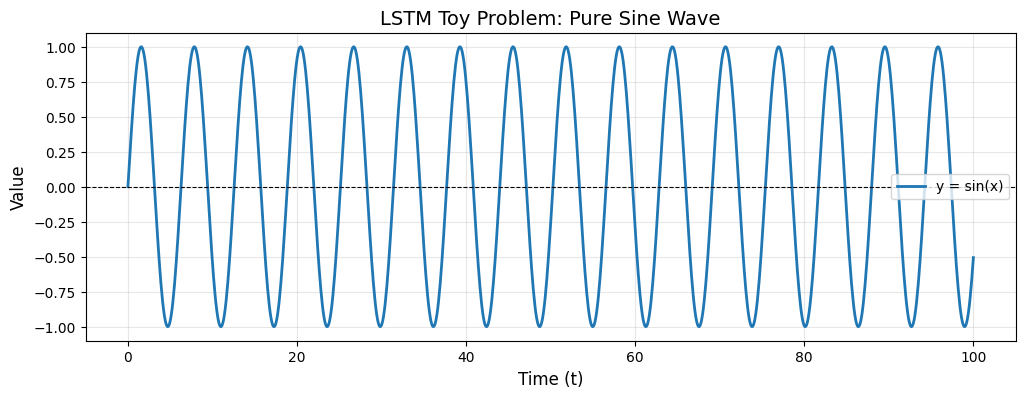

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(X, Y, label='y = sin(x)', color='#1f77b4', linewidth=2)
plt.title('LSTM Toy Problem: Pure Sine Wave', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [4]:
from tensorflow.keras.models import Sequential

In [15]:
Spilt_idx = 800
Y = tf.cast(Y, tf.float32)
Y_train = tf.expand_dims(Y[:Spilt_idx], -1)
Y_CV = tf.expand_dims(Y[Spilt_idx:], -1)

In [16]:
windowsize = 20
batchsize = 32
Trian_set = tf.keras.utils.timeseries_dataset_from_array(
    data = Y_train[:-1],
    targets = Y_train[windowsize:],
    sequence_length = windowsize,
    batch_size = batchsize
)
CV_set = tf.keras.utils.timeseries_dataset_from_array(
    data = Y_CV[:-1],
    targets = Y_CV[windowsize:],
    sequence_length = windowsize,
    batch_size = batchsize
)

In [17]:
model = Sequential(
    [
        tf.keras.layers.Input(shape = (windowsize, 1)),
        tf.keras.layers.LSTM(units = 32, activation = 'tanh'),
        tf.keras.layers.Dense(units = 1, activation= 'linear')
    ],name = 'My_LSTM'
)
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.05), loss = 'mse'
)
model.summary()

Model: "My_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    Trian_set, validation_data = CV_set, epochs = 20
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1710 - val_loss: 0.0014
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 1.2794e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1069e-04 - val_loss: 3.8814e-05
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4428e-05 - val_loss: 4.1644e-06
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8871e-06 - val_loss: 1.7286e-06
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3718e-06 - val_loss: 1.1049e-06
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.5351e-07 - val_loss: 8.6366e-07
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.4798e-07 - val_loss: 6.8073e-07
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0821e-07 - val_loss: 5.5615e-07
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0992e-07 - val_loss: 4.7946e-07
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.4277e-07 - val_loss: 4.2

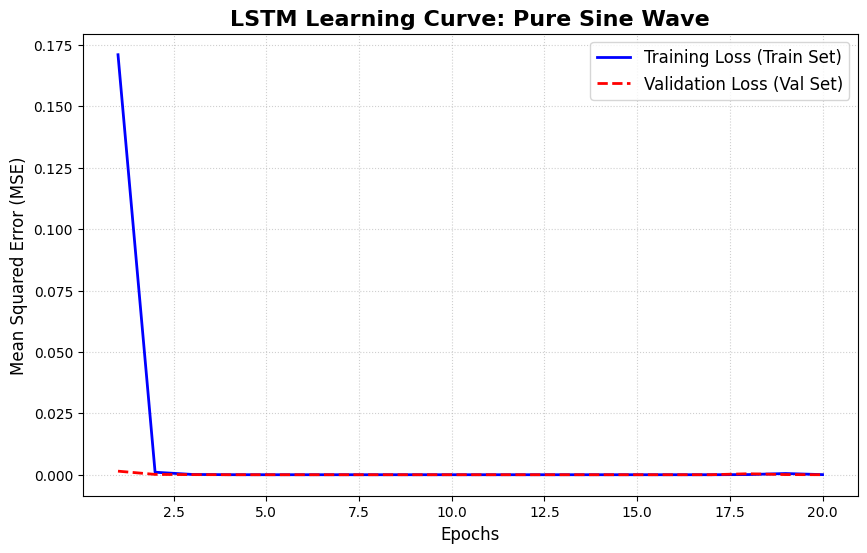

In [19]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, 21)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, training_loss, 'b-', linewidth=2, label='Training Loss (Train Set)')
plt.plot(epochs_range, validation_loss, 'r--', linewidth=2, label='Validation Loss (Val Set)')

plt.title('LSTM Learning Curve: Pure Sine Wave', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


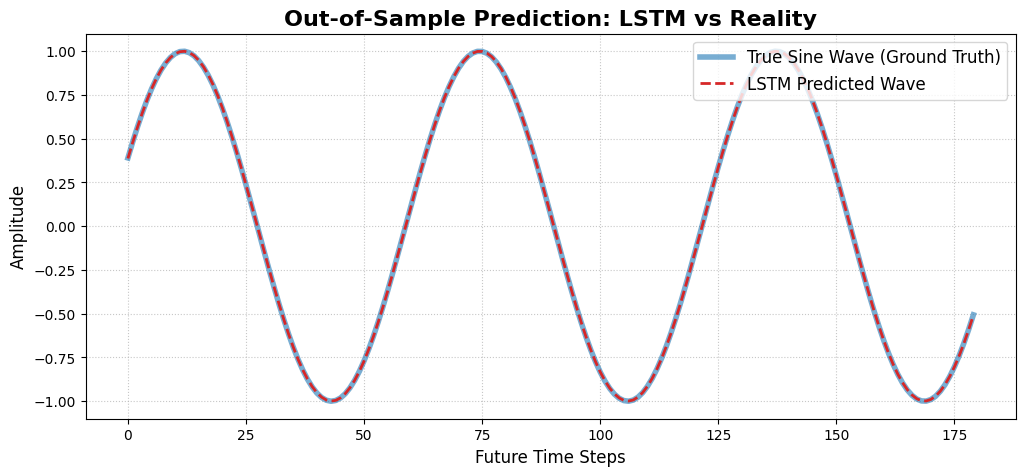

In [ ]:
predicted_Y = model.predict(CV_set)

true_Y = Y_CV[windowsize:].numpy() 

plt.figure(figsize=(12, 5))

plt.plot(true_Y, label='True Sine Wave (Ground Truth)', color='#1f77b4', linewidth=4, alpha=0.6)

plt.plot(predicted_Y, label='LSTM Predicted Wave', color='#d62728', linestyle='--', linewidth=2)

plt.title('Out-of-Sample Prediction: LSTM vs Reality', fontsize=16, fontweight='bold')
plt.xlabel('Future Time Steps', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()